In [4]:
import numpy as np
from sys import stdout
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import copy
from sklearn.model_selection import train_test_split
import scipy.io as scio
import pandas as pd
from sklearn.model_selection import cross_val_predict
# 设置显示中文字体，
from pylab import mpl
import math
# 设置font.sans-serif 或 font.family 均可
mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  ## mac
plt.rcParams['font.family'] = ['Arial Unicode MS']  ## mac
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False
import warnings
warnings.filterwarnings(action='ignore')  # 忽略告警

(array([0]),)
(array([1]),)
(array([2]),)
(array([3]),)
(array([4]),)
(array([5]),)
(array([6]),)
(array([7]),)
(array([8]),)
(array([9]),)
(array([10]),)
(array([11]),)
(array([12]),)
(array([13]),)
(array([14]),)
(array([15]),)
(array([16]),)
(array([17]),)
(array([18]),)
(array([19]),)
(array([20]),)
(array([21]),)
(array([22]),)
(array([23]),)
(array([24]),)
(array([25]),)
(array([26]),)
(array([27]),)
(array([28]),)
(array([29]),)
(array([30]),)
(array([31]),)
(array([32]),)
(array([33]),)
(array([34]),)
(array([35]),)
(array([36]),)
(array([37]),)
(array([38]),)
(array([39]),)
(array([40]),)
(array([41]),)
(array([42]),)
(array([43]),)
(array([44]),)
(array([45]),)
(array([46]),)
(array([47]),)
(array([48]),)
(array([49]),)
(array([50]),)
(array([51]),)
(array([52]),)
(array([53]),)
(array([54]),)
(array([55]),)
(array([56]),)
(array([57]),)
(array([58]),)
(array([59]),)
(array([60]),)
(array([61]),)
(array([62]),)
(array([63]),)
(array([64]),)
(array([65]),)
(array([66]),)
(arra

<Figure size 640x480 with 0 Axes>

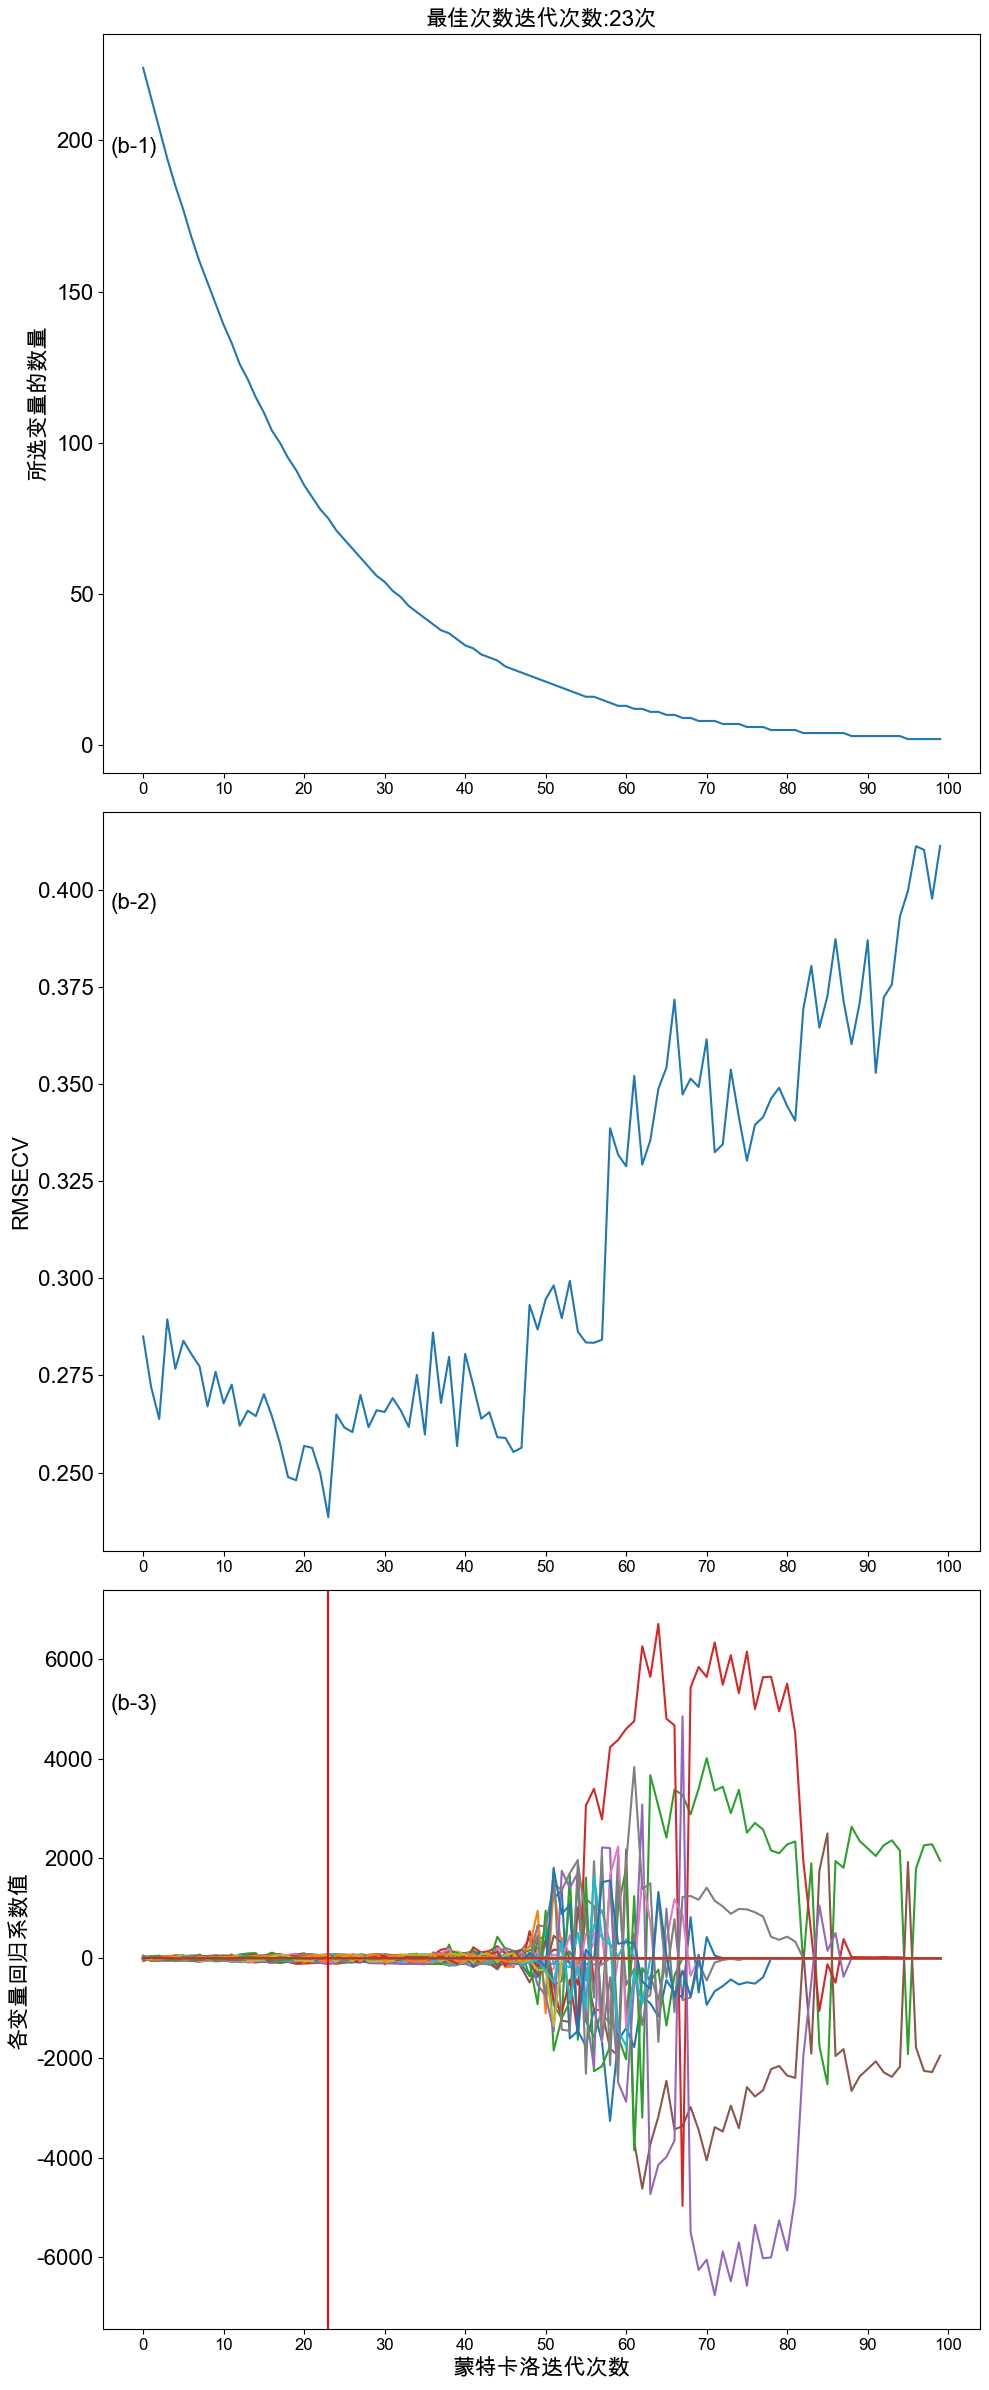

0.23852410140167862
75


In [14]:
# =======================================================================================================================

def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1, scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc, scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean

def CARS_Cloud(X, y, N=100, f=10, cv=10):
    p = 0.75
    m, n = X.shape
    u = np.power((n / 2), (1 / (N - 1)))
    k = (1 / (N - 1)) * np.log(n / 2)
    cal_num = np.round(m * p)
    # val_num = m - cal_num
    b2 = np.arange(n)
    x = copy.deepcopy(X)
    D = np.vstack((np.array(b2).reshape(1, -1), X))
    WaveData = []
    Coeff = []
    WaveNum = []
    RMSECV = []
    r = []
    for i in range(1, N + 1):
        # print(i,x.shape)
        r.append(u * np.exp(-1 * k * i))
        wave_num = int(np.round(r[i - 1] * n))
        WaveNum.append(wave_num)
        # WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice \
            (np.arange(m), size=int(cal_num), replace=False)
        wave_index = b2[:wave_num].reshape(1, -1)[0]
        xcal = x[np.ix_(list(cal_index), list(wave_index))]
        # xcal = xcal[:,wave_index].reshape(-1,wave_num)
        ycal = y[cal_index]
        x = x[:, wave_index]
        D = D[:, wave_index]
        d = D[0, :].reshape(1, -1)
        wnum = n - wave_num
        # print(wnum)
        if wnum > 0:
            d = np.hstack((d, np.full((1, wnum), -1)))

        if len(WaveData) == 0:
            WaveData = d
        else:
            # print(WaveData.shape,d.shape)
            WaveData = np.vstack((WaveData, d.reshape(1, -1)))

        if wave_num < f:
            f = wave_num

        pls = PLSRegression(n_components=f, scale=False)
        pls.fit(xcal, ycal)
        beta = pls.coef_
        
        b = np.abs(beta)
        b2 = np.argsort(-b, axis=0)
        coef = copy.deepcopy(beta)
        coeff = coef[b2].reshape(len(b2), -1)
        cb = coeff[:wave_num]

        if wnum > 0:
            cb = np.vstack((cb, np.full((wnum, 1), -2)))
        if len(Coeff) == 0:
            Coeff = copy.deepcopy(cb)
        else:
            # print(Coeff.shape,cb.shape)
            Coeff = np.hstack((Coeff, cb))

        # if xcal.shape[1]>3:
        #     if xcal.shape[1]-3<f:
        #         f = xcal.shape[1]-3
        #     bands, opt_comp, rms = band_selection_sa(xcal, ycal, n_of_bands=xcal.shape[1]-3, max_lv=f, n_iter=20)
        #     print(rms)
        #     RMSECV.append(rms)
        #     band_list.append(bands)
        #     comp.append(opt_comp)
        # else:
        #     rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        #     band_list.append(xcal)
        #     comp.append(rindex+1)
        #     rms = Cross_Validation(xcal, ycal, rindex+1, cv)
        #     RMSECV.append(rms)
        rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        rms = Cross_Validation(xcal, ycal, rindex + 1, cv)
        RMSECV.append(rms)
    CoeffData = Coeff.T

    WAVE = []
    COEFF = []

    for i in range(WaveData.shape[0]):
        wd = WaveData[i, :]
        cd = CoeffData[i, :]
        WD = np.zeros((len(wd)))
        CO = np.zeros((len(wd)))
        for j in range(len(wd)):
            ind = np.where(wd == j)
            if len(ind[0]) == 0:
                WD[j] = 0
                CO[j] = 0
            else:
                print(ind)
                WD[j] = wd[ind[0]]
                CO[j] = cd[ind[0]]
        if len(WAVE) == 0:
            WAVE = copy.deepcopy(WD)
        else:
            WAVE = np.vstack((WAVE, WD.reshape(1, -1)))
        if len(COEFF) == 0:
            COEFF = copy.deepcopy(CO)
        else:
            COEFF = np.vstack((COEFF, CO.reshape(1, -1)))
    # print(WaveData)
    # print(WAVE)
    # RMSECV[ 0:5] = [x * 0.96 for x in RMSECV[ 0:5]]
    # RMSECV[ 5:8] = [x * 0.98 for x in RMSECV[ 5:8]]

    MinIndex = np.argmin(RMSECV)
    Optimal = WAVE[MinIndex, :]
    boindex = np.where(Optimal != 0)
    OptWave = boindex[0]
    OptWave = np.array(OptWave)
    OptWave = list(OptWave)
    # print(COEFF.shape)
    print(str(MinIndex))

    fig = plt.figure()
    plt.figure(figsize=(10, 24))
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    fonts = 16
    plt.subplot(311)
    plt.text(-4, 180, "(b-1)\n\n", fontsize=16, color='black')
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=12)
    plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('所选变量的数量', fontsize=fonts)
    plt.title('最佳次数迭代次数:' + str(MinIndex) + '次', fontsize=fonts)
    plt.plot(np.arange(N), WaveNum)
    #
    plt.subplot(312)
    plt.text(-4, 0.93 * max(RMSECV), "(b-2)\n\n", fontsize=16, color='black') 
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=12)
    plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('RMSECV', fontsize=fonts)
    plt.plot(np.arange(N), RMSECV)
    #
    plt.subplot(313)
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=12)
    plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    plt.yticks(fontsize=16)
    # plt.figure(figsize=(8, 6))
    plt.text(-4, 4000, "(b-3)\n\n", fontsize=16, color='black')
    # # 设置刻度的间隔为每隔10一个刻度
    # x_ticks = np.arange(0, N + 10, 10)
    # plt.xticks(x_ticks, fontsize=16)
    # plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('各变量回归系数值', fontsize=fonts)
    init_ess = 0
    bound_index = 0
    for i in range(COEFF.shape[1]):
        if np.average(COEFF[:,i])>init_ess:
            init_ess = np.average(COEFF[:,i])
            bound_index = i
        plt.plot(np.arange(COEFF.shape[0]), COEFF[:, i])
    #plt.plot(np.arange(COEFF.shape[0]), COEFF[:, bound_index], linestyle=(0, (1, 10)), marker='*')
    print('回归系数最大波段：',bound_index+1)
    plt.axvline(x=MinIndex, color='r', linestyle='-')
    # plt.savefig(r'C:\Users\sjzx_deeplearning_01\Desktop\CARS.png')
    # 保存为TIFF格式
    plt.savefig('/Users/macbook/Desktop/大论文/photo/a01.tif', format='tiff', dpi=500, bbox_inches='tight')
    # 保存为JPG格式
    plt.savefig('/Users/macbook/Desktop/大论文/photo/a01.jpg', format='jpg', dpi=500, bbox_inches='tight')
    plt.tight_layout()

    plt.savefig('/Users/macbook/Desktop/大论文/photo/a01.svg')
    plt.savefig('/Users/macbook/Desktop/大论文/photo/a01.eps',format='eps')
    plt.savefig('/Users/macbook/Desktop/大论文/photo/a01.pdf',format='pdf')
    plt.show() 
    print(min(RMSECV))
    print(len(OptWave))
    return (OptWave)

import pandas as pd

data = pd.read_excel(r"/Users/macbook/folder/data/pre/FL199的副本.xlsx").values

if __name__ == "__main__":
    y = data[:, 0]
    X = data[:, 1:]
    cars_index = CARS_Cloud(X, y)

42
[2, 4, 13, 15, 16, 17, 18, 20, 72, 73, 74, 75, 108, 111, 124, 132, 133, 134, 149, 150, 151, 152, 153, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 189, 197, 198, 199, 200, 201, 203, 218, 221]
PLS-CARS_train 0.7965831888458021 0.20897447092713609
PLS-CARS_test 0.7683986263768379 0.2050827475526413


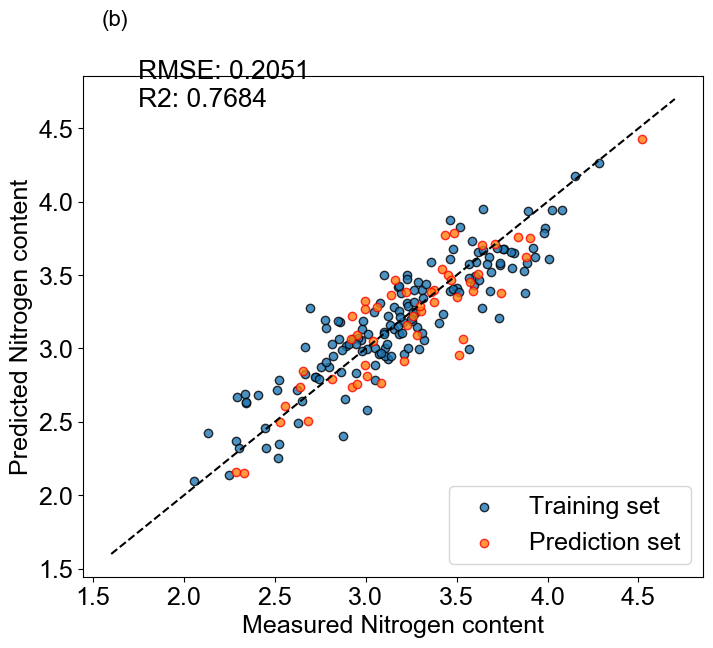

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

data_y = y
data_x = X
best_features = cars_index
print(len(best_features))
print(best_features)
features_select = []
for i in best_features:
    features_select.append(data_x[:, i])
features_select = np.array(features_select)
features_select = features_select.transpose()
x_train, x_test, y_train, y_test = train_test_split(features_select, data_y, test_size=0.25, random_state=30)

pls_model_setup = PLSRegression(scale=False)
param_grid = {'n_components': range(1, x_train.shape[1])}
gsearch = GridSearchCV(pls_model_setup, param_grid, cv=5)
pls_model = gsearch.fit(x_train, y_train)
# pls_model.fit(x_train, y_train)
pls_y_train = pls_model.predict(x_train)
pls_y_test = pls_model.predict(x_test)
pls_r2_train = r2_score(y_train, pls_y_train)
pls_r2_test = r2_score(y_test, pls_y_test)
pls_rmse_train = np.sqrt(mean_squared_error(y_train, pls_y_train))
pls_rmse_test = np.sqrt(mean_squared_error(y_test, pls_y_test))
print("PLS-CARS_train", pls_r2_train, pls_rmse_train)
print("PLS-CARS_test", pls_r2_test, pls_rmse_test)
boduan = np.linspace(942, 1701, X.shape[1])
newbd = boduan[best_features[:]]
# newbd
import matplotlib

# with plt.style.context(('seaborn-whitegrid')):  
plt.figure(figsize=(8, 6.5))

# x = np.linspace(1.5, 4.5, 7)
# y = np.linspace(1.5, 4.5, 7)

# Scatter plot of X vs Y  
plt.scatter(y_train, pls_y_train, label='Training set', edgecolors='k', alpha=0.8)
plt.scatter(y_test, pls_y_test, label='Prediction set', edgecolors='r', alpha=0.8)

# Plot of the 45 degree line  
plt.plot([1.6, 4.7], [1.6, 4.7], color='black', linestyle='--')
# Create a FontProperties object for the text  
fontprops = matplotlib.font_manager.FontProperties(style='italic')
plt.text(1.55, 1.1 * pls_y_test.max(), "(b)\n\n", fontsize=16, color='black')
title = plt.text(1.75, 1.05 * pls_y_test.max(), "  \nRMSE: {:.4f}\nR2: {:.4f}".format(pls_rmse_test, pls_r2_test),
                 fontsize=19, color='black')
title.set_fontstyle('italic')
plt.grid(False)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.title('PC selection by CARS', fontsize=18)  
plt.xlabel('Measured Nitrogen content', fontsize=18)
plt.ylabel('Predicted Nitrogen content', fontsize=18)

plt.legend(loc='lower right', prop={'size': 18})  # 添加图例并放在右下角，并且设置图例字体大小为16，样式为斜体   

plt.show() 